<a href="https://colab.research.google.com/github/Junhojuno/pytorch-tutorial/blob/master/mnist_linear_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [0]:
import torch
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import random

device = "cuda" if torch.cuda.is_available() else "cpu"

random.seed(777)
torch.manual_seed(777)
if device == 'cuda':
torch.cuda.manual_seed_all(777)

In [0]:
# parameters setting
training_epochs = 15
batch_size = 100

In [0]:
# MNIST dataset load
# transforms.ToTensor() : mnist 데이터를 (channel, height, width)의 torch 데이터 형태로 바꿔주는 역할
mnist_train = datasets.MNIST(root='MNIST_data/', train=True, transform=transforms.ToTensor(), download=True)
mnist_test = datasets.MNIST(root='MNIST_data/', train=False, transform=transforms.ToTensor(), download=True)

  0%|          | 0/9912422 [00:00<?, ?it/s]

9920512it [00:00, 25732649.74it/s]                            


Extracting MNIST_data/MNIST/raw/train-images-idx3-ubyte.gz


32768it [00:00, 437831.96it/s]
  1%|          | 16384/1648877 [00:00<00:11, 144031.57it/s]

Extracting MNIST_data/MNIST/raw/train-labels-idx1-ubyte.gz


1654784it [00:00, 7461710.97it/s]                            
8192it [00:00, 170305.96it/s]


Extracting MNIST_data/MNIST/raw/t10k-images-idx3-ubyte.gz
Extracting MNIST_data/MNIST/raw/t10k-labels-idx1-ubyte.gz
Processing...
Done!


In [0]:
mnist_train.train_data.shape

/usr/local/lib/python3.6/dist-packages/torchvision/datasets/mnist.py:53: UserWarning: train_data has been renamed data
  warnings.warn("train_data has been renamed data")


torch.Size([60000, 28, 28])

In [0]:
# batch_size크기만큼 묶음으로 묶여있음 (600묶음, total batch)
# drop_last : 전체 데이터를 batch_size로 나눴을때 나머지를 버릴건지 여부
data_loader = torch.utils.data.DataLoader(dataset=mnist_train, batch_size=batch_size,
                                          shuffle=True, drop_last=True)

In [0]:
# 784 input_dim, 10 output_dim 
linear = torch.nn.Linear(in_features=784, out_features=10, bias=True).to(device)

In [0]:
# cost and optimizer
# CrossEntropyLoss()에 내부적으로 softmax계산
cost_func = torch.nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.SGD(params=linear.parameters(), lr=0.1)

In [0]:
for epoch in range(training_epochs):
  avg_cost = 0
  total_batch = len(data_loader)
  
  for X, Y in data_loader: # batch size만큼이 한뭉탱이로 매 iteration마다 나옴
    X = X.view(-1, 28 * 28).to(device) # (batch_size, 784)로 input image를 맞춰주자
    Y = Y.to(device)
    
    optimizer.zero_grad() # gradient 초기화 (앞선 배치의 영향을 받으면 지금 배치의 순수한 gradient를 구할 수 없겠죠?)
    hypothesis = linear(X) # prediction
    cost = cost_func(hypothesis, Y)
    cost.backward()
    optimizer.step()
    
    avg_cost += cost / total_batch
  
  print("Epoch : {}, cost = {:.9f}".format(epoch+1, avg_cost))

print("Learning Finished...!")

Epoch : 1, cost = 0.336239845
Epoch : 2, cost = 0.319617778
Epoch : 3, cost = 0.309010953
Epoch : 4, cost = 0.301845759
Epoch : 5, cost = 0.296199441
Epoch : 6, cost = 0.291807830
Epoch : 7, cost = 0.288084477
Epoch : 8, cost = 0.285010248
Epoch : 9, cost = 0.282577038
Epoch : 10, cost = 0.280268490
Epoch : 11, cost = 0.278352112
Epoch : 12, cost = 0.276426613
Epoch : 13, cost = 0.274807036
Epoch : 14, cost = 0.273417056
Epoch : 15, cost = 0.271959990
Learning Finished...!


/usr/local/lib/python3.6/dist-packages/torchvision/datasets/mnist.py:58: UserWarning: test_data has been renamed data
  warnings.warn("test_data has been renamed data")
/usr/local/lib/python3.6/dist-packages/torchvision/datasets/mnist.py:48: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")


Accuracy: 0.8752999901771545
Label:  8
Prediction:  3


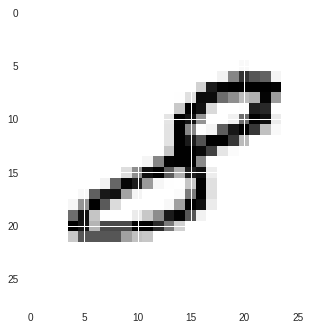

In [0]:
# Test the model using test sets
with torch.no_grad():
    X_test = mnist_test.test_data.view(-1, 28 * 28).float().to(device)
    Y_test = mnist_test.test_labels.to(device)

    prediction = linear(X_test)
    correct_prediction = torch.argmax(prediction, 1) == Y_test
    accuracy = correct_prediction.float().mean()
    print('Accuracy:', accuracy.item())

    # Get one and predict
    r = random.randint(0, len(mnist_test) - 1)
    X_single_data = mnist_test.test_data[r:r + 1].view(-1, 28 * 28).float().to(device)
    Y_single_data = mnist_test.test_labels[r:r + 1].to(device)

    print('Label: ', Y_single_data.item())
    single_prediction = linear(X_single_data)
    print('Prediction: ', torch.argmax(single_prediction, 1).item())

    plt.imshow(mnist_test.test_data[r:r + 1].view(28, 28), cmap='Greys', interpolation='nearest')
    plt.show()

- 8인데 3이라고 예측...